In [10]:
from google.colab import drive
drive.mount('/content/drive')

# path_drive = '/content/drive/MyDrive/simulacions/04-05-26/equilibration'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Computing permeation events... (please wait)
WT1:1854 permeated through the nanotubes along -z direction at frame 9
WT1:948 permeated through the nanotubes along -z direction at frame 14
WT1:1778 permeated through the nanotubes along +z direction at frame 20
WT1:1911 permeated through the nanotubes along -z direction at frame 22
WT1:7133 permeated through the nanotubes along +z direction at frame 23
WT1:111 permeated through the nanotubes along -z direction at frame 25
WT1:3935 permeated through the nanotubes along +z direction at frame 25
WT1:1370 permeated through the nanotubes along -z direction at frame 26
WT1:1880 permeated through the nanotubes along +z direction at frame 26
WT1:4065 permeated through the nanotubes along +z direction at frame 26
WT1:509 permeated through the nanotubes along +z direction at frame 27
WT1:2608 permeated through the nanotubes along +z direction at frame 27
WT1:3016 permeated through the nanotubes along +z direction at frame 31
WT1:3161 permeated thro

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


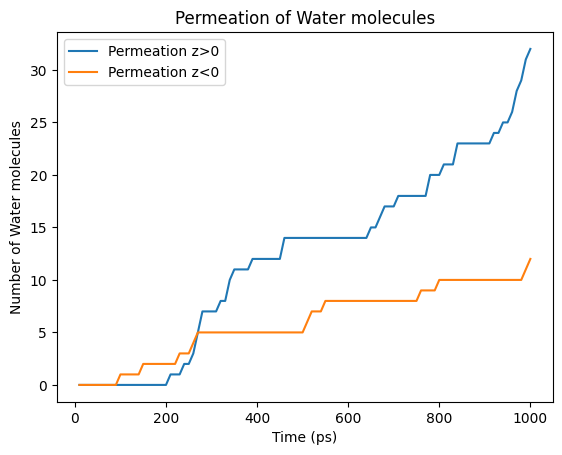

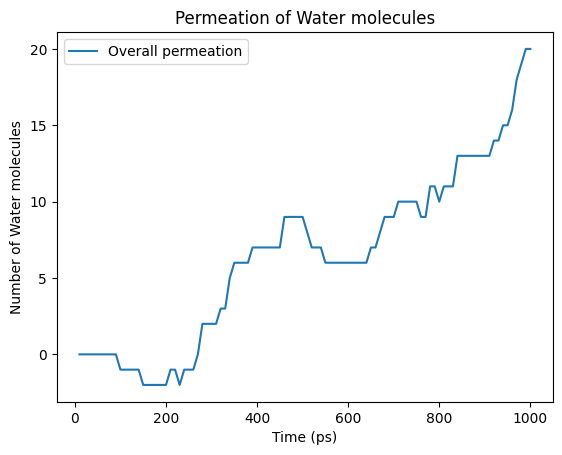

In [11]:
!pip install MDAnalysis

import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

# --- region of crossing ---
upper_end = 6.754
lower_end = -6.754

# Start counting permeation events after this number of frames
skip_frame = 0
output_file = "permeation.dat"

psf_path = '/content/drive/MyDrive/simulacions/04-05-26/equilibration/system.psf'
dcd_path = '/content/drive/MyDrive/simulacions/04-05-26/equilibration/MDequil.dcd'

# Load your trajectory
u = mda.Universe(psf_path, dcd_path)
wat = u.select_atoms("name OH2")

seg_list = wat.segids
resids = wat.resids
num_atoms = len(wat)
labels = np.zeros(num_atoms, dtype=int)

num1 = 0
num2 = 0

# Each water molecule has a label, which has 5 possible values
#  2: Above the nanotube layer
# -2: Below the nanotube layer
#  1: Inside the nanotube layer, entering from upper surface
# -1: Inside the nanotube layer, entering from lower surface
#  0: Inside the nanotube layer from the beginning

print("Computing permeation events... (please wait)")

time=[]
permeation_pos=[]
permeation_neg=[]

with open(output_file, "w") as f:
    f.write("# frame +z -z \n")

    for ts in u.trajectory:
        z_coords = wat.positions[:, 2]
        old_labels = labels.copy()
        for i, z in enumerate(z_coords):
            old_label = old_labels[i]
            segname = seg_list[i]
            resid = resids[i]

            if z > upper_end:
                new_label = 2
                if old_label == -1:
                    print(f"{segname}:{resid} permeated through the nanotubes along +z direction at frame {ts.frame}")
                    if ts.frame >= skip_frame:
                        num1 += 1
            elif z < lower_end:
                new_label = -2
                if old_label == 1:
                    print(f"{segname}:{resid} permeated through the nanotubes along -z direction at frame {ts.frame}")
                    if ts.frame >= skip_frame:
                        num2 += 1
            elif abs(old_label) > 1:
                new_label = old_label // 2
            else:
                new_label = old_label

            labels[i] = new_label

        time.append(ts.time)
        permeation_pos.append(num1)
        permeation_neg.append(num2)
        f.write(f"{round(ts.time)} {num1} {num2}\n")

# Summary
nf = len(u.trajectory) - skip_frame
if nf >= 0:
    print(f"\nThe total number of permeation events during {nf} frames in +z direction is: {num1}")
    print(f"\nThe total number of permeation events during {nf} frames in -z direction is: {num2}")
else:
    print(f"The specified first frame ({skip_frame}) is larger than the total number of frames.")

print("Time evolution saved in a .dat file")

#Plot
plt.plot(time, permeation_pos, label='Permeation z>0')
plt.plot(time, permeation_neg, label='Permeation z<0')
plt.xlabel('Time (ps)')
plt.ylabel('Number of Water molecules')
plt.title('Permeation of Water molecules')
plt.legend()
plt.show()

#plot overall permeation
overall= [p - n for p, n in zip(permeation_pos, permeation_neg)]
plt.plot(time, overall, label='Overall permeation')
plt.xlabel('Time (ps)')
plt.ylabel('Number of Water molecules')
plt.title('Permeation of Water molecules')
plt.legend()
plt.show()